# Connect to the Drive repo

In [ ]:
from pathlib import Path
import os, sys, subprocess

PUBLIC_ID = '1hpzEta1Ub_FlVQszrYXsis0Phirrjh81'
DEST_DIR = Path("/content/drive/My Drive/Finding_ES_LLM")
DRIVE_ROOT = Path("/content/drive")

# Mount

if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")

# 2) check if the repo folder already exists in their Drive
if not DEST_DIR.exists() or not any(DEST_DIR.iterdir()):
    print("Repo not found in your Drive. Downloading …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown>=5"])
    DEST_DIR.mkdir(parents=True, exist_ok=True)
    cmd = [
        "gdown", f"https://drive.google.com/drive/folders/{PUBLIC_ID}",
        "--folder", "-O", str(DEST_DIR)
    ]
    subprocess.check_call(cmd)
else:
    print("Repo already present in your Drive -> skipping download")

# 3) put it on sys.path so imports work
sys.path.insert(0, str(DEST_DIR))
print("Repo ready at:", DEST_DIR)

# This is the notebook where I built most of the plots

For developing the visualization I already had all the results from the experiments. The plots are built out of these, which were stored/pickled/annotated/copied etc.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle
import seaborn as sns
from visualization import *
import pandas as pd
np.random.seed(42)

## Probing/Intervention Study

Here we visualize:



1.   Top 3 accuracies from probed models (resid)
2.   Full accuracies from probed models (resid)
3.   Difference between behavioral accuracy vs probe accuracy (extracted during the intervention study)
4.   Different probes accuracies on llama



In [ ]:
with open(f'{DEST_DIR}/accuracies/gpt_line.pkl', 'rb') as file:
    gpt = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/gpt-j_line.pkl', 'rb') as file:
    gpt_j = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/llama_line.pkl', 'rb') as file:
    llama = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/llama_instruct_line.pkl', 'rb') as file:
    llama_instruct = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/llama_medium_line.pkl', 'rb') as file:
    llama_medium = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/llama_medium_instruct_line.pkl', 'rb') as file:
    llama_medium_instruct = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/pythia_line.pkl', 'rb') as file:
    pythia = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/pythia_instruct_line.pkl', 'rb') as file:
    pythia_deduped = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/yi_line.pkl', 'rb') as file:
    yi = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/yi_instruct_line.pkl', 'rb') as file:
    yi_instruct = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/gemma_line.pkl', 'rb') as file:
    gemma = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/gemma_instruct_line.pkl', 'rb') as file:
    gemma_instruct = pickle.load(file)

models = [
          sorted(gpt), sorted(gpt_j),
          sorted(yi), sorted(yi_instruct),
          sorted(pythia_deduped), sorted(pythia),
          sorted(llama_medium), sorted(llama_medium_instruct),
          sorted(gemma), sorted(gemma_instruct),
          sorted(llama), sorted(llama_instruct)
          ]
top3 = [model[-3:] for model in models]
top3_avg = [float(np.mean(model)*100) for model in top3]

FileNotFoundError: [Errno 2] No such file or directory: './accuracies/gpt_line.pkl'

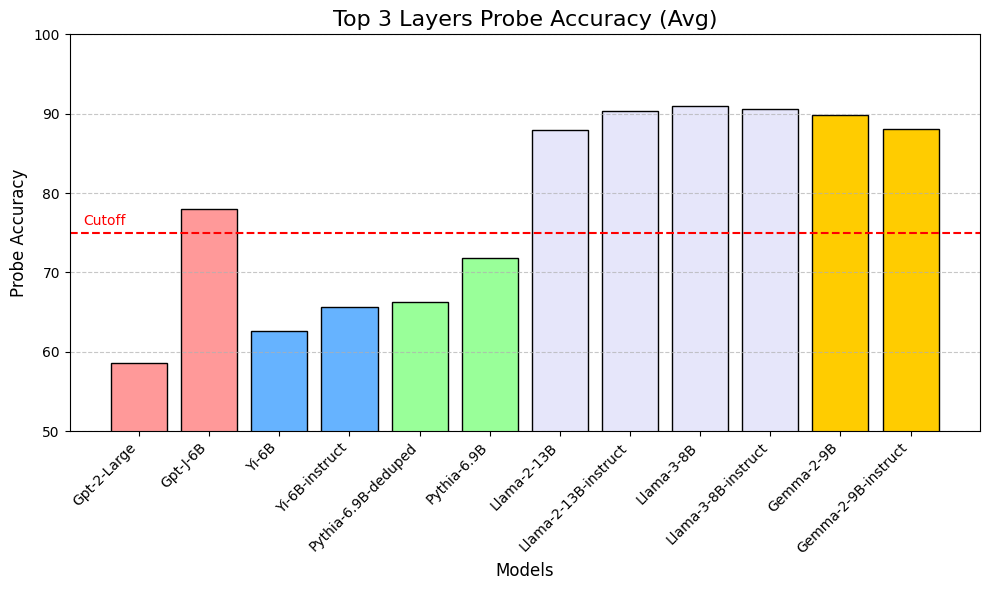

In [ ]:
categories = ['Gpt-2-Large', 'Gpt-J-6B', 'Yi-6B', 'Yi-6B-instruct', 'Pythia-6.9B-deduped', 'Pythia-6.9B', 'Llama-2-13B', 'Llama-2-13B-instruct', 'Llama-3-8B', 'Llama-3-8B-instruct', 'Gemma-2-9B', 'Gemma-2-9B-instruct']
values = top3_avg
colors = ['#FF9999', '#FF9999', '#66B3FF', '#66B3FF', '#99FF99', '#99FF99', '#E6E6FA', '#E6E6FA', '#E6E6FA','#E6E6FA', '#FFCC00',  '#FFCC00']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, edgecolor='black')
cutoff_value = 75
plt.axhline(y=cutoff_value, color='red', linestyle='--', linewidth=1.5, label='Cutoff')
plt.text(-0.80, cutoff_value + 1, 'Cutoff', color='red', fontsize=10)
plt.title('Top 3 Layers Probe Accuracy (Avg)', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Probe Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(50, 100)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


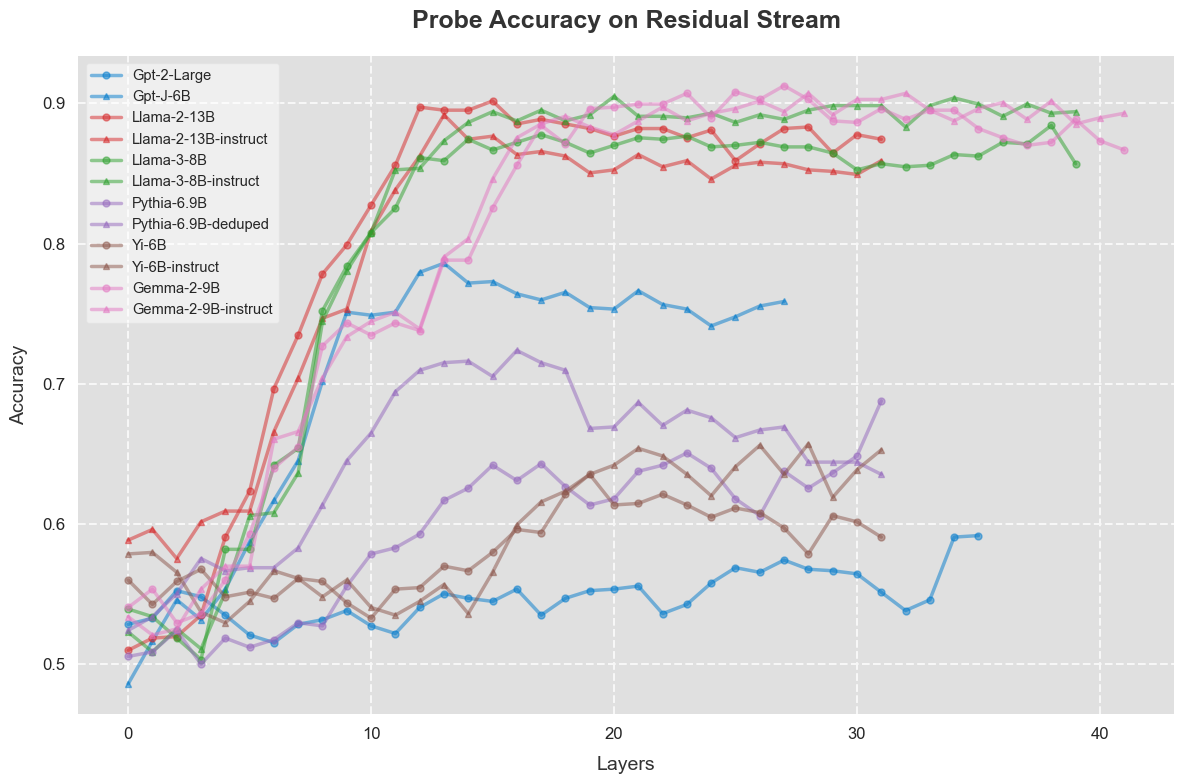

In [ ]:
pretty_line_mass(
    gpt, gpt_j,llama, llama_instruct, llama_medium, llama_medium_instruct,  pythia_deduped, pythia, yi, yi_instruct,  gemma, gemma_instruct, #
    labels = ['Gpt-2-Large', 'Gpt-J-6B', 'Llama-2-13B', 'Llama-2-13B-instruct', 'Llama-3-8B', 'Llama-3-8B-instruct', 'Pythia-6.9B', 'Pythia-6.9B-deduped', 'Yi-6B', 'Yi-6B-instruct',  'Gemma-2-9B', 'Gemma-2-9B-instruct'],
    )

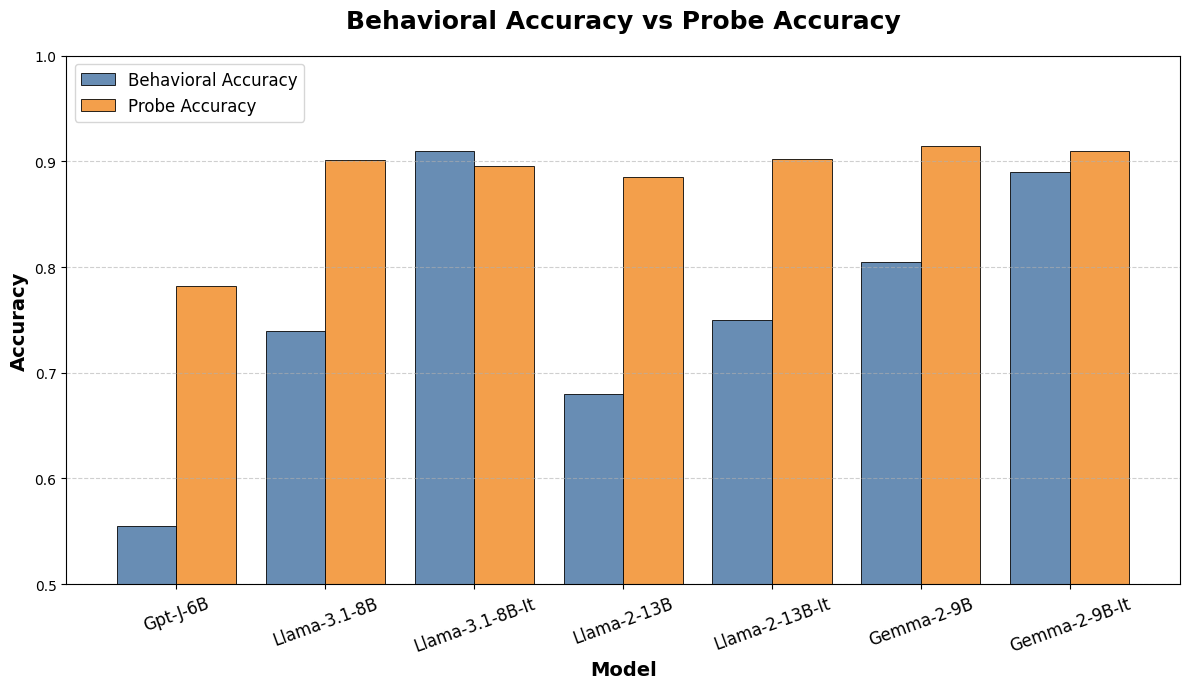

In [ ]:
behav = [(100 - 46 + 100 - 43) / 200,           # Gpt-J-6B
         (100 + 100 - 52) / 200,                # Llama-3.1-8B
         (100 - 1 + 100 - 17) / 200,            # Llama-3.1-8B-It
         (100 - 15 + 100 - 49) / 200,           # Llama-2-13B
         (100 - 28 + 100 - 22) / 200,           # Llama-2-13B-It
         (100 - 5 + 100 - 34) / 200,            # Gemma-2-9B
         (100 - 8 + 100 - 14) / 200]            # Gemma-2-9B-It
accs = [0.782, 0.901, 0.896, 0.885, 0.902, 0.915, 0.910]

indices = np.arange(len(behav))
models = ['Gpt-J-6B', 'Llama-3.1-8B', 'Llama-3.1-8B-It', 'Llama-2-13B', 'Llama-2-13B-It', 'Gemma-2-9B', 'Gemma-2-9B-It']
bar_width = 0.4

plt.figure(figsize=(12, 7))

colors = ['#4E79A7', '#F28E2B']
bars1 = plt.bar(indices - bar_width / 2, behav, bar_width, label='Behavioral Accuracy', color=colors[0], alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = plt.bar(indices + bar_width / 2, accs, bar_width, label='Probe Accuracy', color=colors[1], alpha=0.85, edgecolor='black', linewidth=0.7)

plt.xlabel('Model', fontsize=14, weight='bold')
plt.ylabel('Accuracy', fontsize=14, weight='bold')
plt.title('Behavioral Accuracy vs Probe Accuracy', fontsize=18, weight='bold', pad=20)
plt.xticks(indices, models, rotation=20, fontsize=12)
plt.ylim(0.5, 1)
plt.legend(fontsize=12, loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
heads = np.array([99, 90, 97-17, 100-17, 43-28, 97-28, 86-22, 100-22, 17-8, 94-8, 28-14, 99-14])
resid = np.array([90, 97, 91-52, 84-52, 33-15, 87-15, 83-49, 99-49, 80-5, 71, 53-34, 99-34])

print("Avg difference head-resid interventions: ", np.mean(heads-resid))

strengths_r = np.array([0.714, 0.875, 0.625, 0.545, 1.20, 6.428, 2.142, 1.748, 0.765, 0.468, 1.875, 2.6, 4.666, 3.928])
strengths_h = np.array([0.142, 0.312, 0.219, 0.100, 0.050, 1.129, 1.130, 0.640, 0.139, 0.195, 0.150, 0.120, 1.375, 1.130])

strengths_diff = strengths_r - strengths_h
average_strength = np.mean(strengths_diff)
std_strength = np.std(strengths_diff)

print("Average Strength Difference:", average_strength)
print("Standard Deviation of Strength Difference:", std_strength)

Avg difference head-resid interventions:  9.166666666666666
Average Strength Difference: 1.5534285714285712
Standard Deviation of Strength Difference: 1.3920353399806709


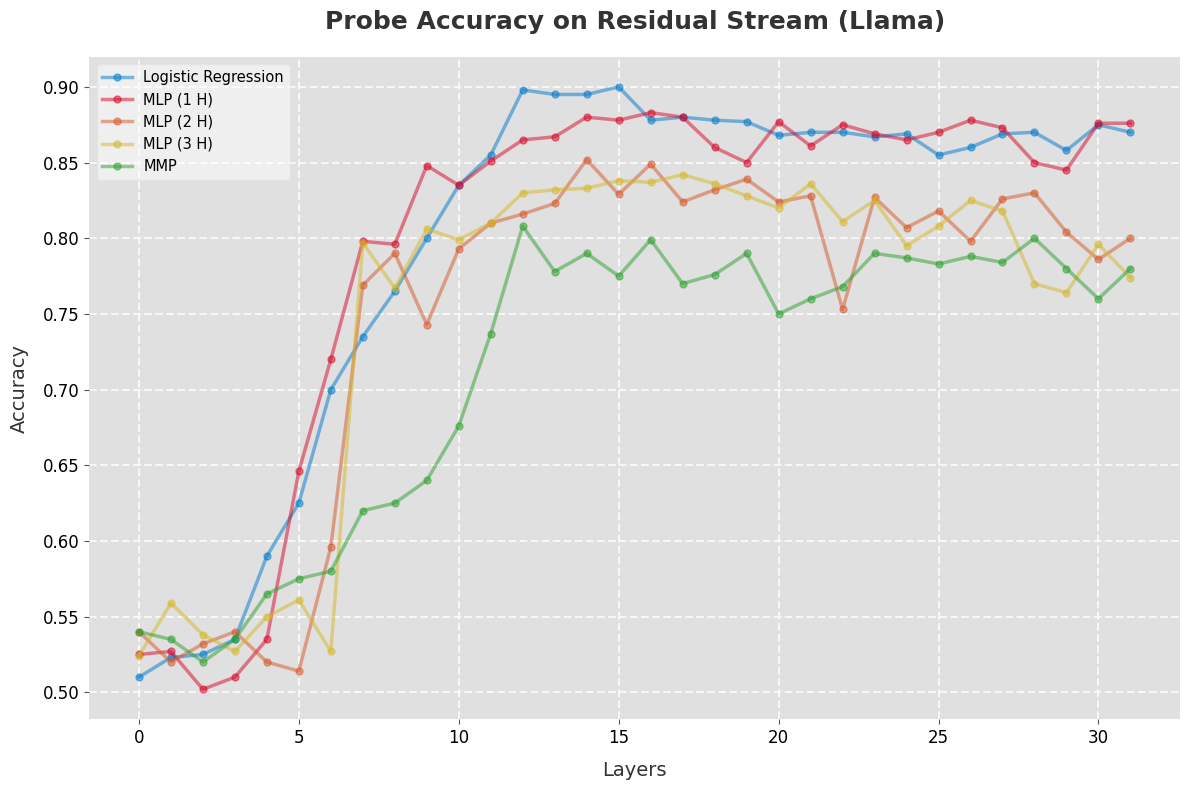

In [ ]:
with open(f'{DEST_DIR}/accuracies/logreg.pkl', 'rb') as file:
    logreg = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/mlp_1.pkl', 'rb') as file:
    mlp_1 = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/mlp_2.pkl', 'rb') as file:
    mlp_2 = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/mlp_3.pkl', 'rb') as file:
    mlp_3 = pickle.load(file)
with open(f'{DEST_DIR}/accuracies/mmp.pkl', 'rb') as file:
    mmp = pickle.load(file)

top_5_logreg = np.flip(np.sort(logreg)[-5:])
top_5_mmp = np.flip(np.sort(mmp)[-5:])
top_5_mlp_1 = np.flip(np.sort(mlp_1)[-5:])
top_5_mlp_2 = np.flip(np.sort(mlp_2)[-5:])
top_5_mlp_3 = np.flip(np.sort(mlp_3)[-5:])
avg_top_5_logreg = np.mean(top_5_logreg)
avg_top_5_mmp = np.mean(top_5_mmp)
avg_top_5_mlp_1 = np.mean(top_5_mlp_1)
avg_top_5_mlp_2 = np.mean(top_5_mlp_2)
avg_top_5_mlp_3 = np.mean(top_5_mlp_3)

colors = ['#007acc',
        '#d60728',
        '#d65728',
        '#d6b728',
        '#2ca02c']
markers = ['o']

pretty_line_mass(logreg, mlp_1, mlp_2, mlp_3,  mmp,
                 labels=['Logistic Regression', 'MLP (1 H)', 'MLP (2 H)', 'MLP (3 H)', 'MMP'],
                 title='Probe Accuracy on Residual Stream (Llama)',
                 colors = colors,
                 markers = markers)

# Coherence study

Here we visualize:



1.   The cross-dataset task performances
2.   The difference between IFT and non-IFT models
3.   Aggregated scores for estimators
4.   Fine-grained task results for estimators

If you want to see the aggregated scores for models instead, you just have to access the models dictionary in the relevant cells



In [ ]:
def standardize(array):

    mean = np.mean(array)
    std_dev = np.std(array)
    standardized_array = array
    for i in range(len(array)):
        standardized_array[i] = (array[i] - mean) / std_dev

    return standardized_array

neg = np.array([
    0.8217, 0.7236, 0.8340, 0.9223, 0.7393,
    0.6483, 0.8448, 0.8853, 0.7674, 0.6682,
    0.8372, 0.9445, 0.8282, 0.7611, 0.8414,
    0.8457, 0.7296, 0.6221, 0.5701, 0.9304, 0.795
])
disj = np.array([
    0.3147, 0.3515, 0.4821, 0.4916, 0.4352,
    0.5546, 0.5167, 0.7204, 0.6083, 0.5141,
    0.5526, 0.7240, 0.4400, 0.3956, 0.5990,
    0.5676, 0.4642, 0.4972, 0.4489, 0.4972, 0.504
])

conj = np.array([
    0.6071, 0.5535, 0.4414, 0.5563, 0.4564,
    0.2857, 0.5133, 0.5491, 0.4884, 0.5107,
    0.4103, 0.4645, 0.7510, 0.4519, 0.7048,
    0.5906, 0.8537, 0.6662, 0.4795, 0.2667, 0.517
])
inf = np.array([
    0.5705, 0.6366, 0.6952, 0.7338, 0.7111,
    0.6860, 0.7233, 0.7681, 0.7086, 0.6477,
    0.6958, 0.7548, 0.7658, 0.8101, 0.8111,
    0.8865, 0.6144, 0.6157, 0.6791, 0.7424, 0.444
])
inf_ = np.array([
    0.6572, 0.6635, 0.7382, 0.8171, 0.7609,
    0.7304, 0.7509, 0.8075, 0.7049, 0.6396,
    0.7490, 0.8279, 0.7980, 0.8979, 0.8325,
    0.9080, 0.6578, 0.6544, 0.7239, 0.9252, 0.477
])

cross = np.array([
    [-4.95, -5.48, -1.95, 28.28, 3.55, -0.20, 10.70, 47.62, -1.92, 4.84, 1.78, 28.23, 4.31, 15.80, 1.42, 41.78, -13.09, -6.70, 12.76, 6.62],
    [-5.52, -10.14, 5.14, 15.85, 7.20, 2.70, 3.99, 11.96, 6.76, 4.92, 6.96, 23.26, 0.72, -0.21, 7.71, 15.09, 3.20, -0.20, 0.12, -0.30],
    [2.82, 2.47, 0.10, 6.51, -1.30, 0.30, 3.16, 5.82, -3.45, -1.03, 2.73, 0.31, -1.97, -3.04, 0.51, -0.20, -8.43, -5.11, -8.84, -15.23]
]) / 100

NameError: name 'np' is not defined

In [ ]:
likely = cross[0, :]
tqa = cross[1, :]
mulan = cross[2, :]

likely_llama, likely_llama_it, likely_gemma, likely_gemma_it, likely_gptj = np.array_split(likely, 5)
tqa_llama, tqa_llama_it, tqa_gemma, tqa_gemma_it, tqa_gptj = np.array_split(tqa, 5)
mulan_llama, mulan_llama_it, mulan_gemma, mulan_gemma_it, mulan_gptj = np.array_split(mulan, 5)

likely_lr = likely[::4]
tqa_lr = tqa[::4]
mulan_lr = mulan[::4]
likely_mmp = likely[1::4]
tqa_mmp = tqa[1::4]
mulan_mmp = mulan[1::4]
likely_self = likely[2::4]
tqa_self = tqa[2::4]
mulan_self = mulan[2::4]
likely_logit = likely[3::4]
tqa_logit = tqa[3::4]
mulan_logit = mulan[3::4]

In [ ]:
cross_models = {
    'llama': {
        'likely': likely_llama,
        'tqa': tqa_llama,
        'mulan': mulan_llama
    },
    'llama_it': {
        'likely': likely_llama_it,
        'tqa': tqa_llama_it,
        'mulan': mulan_llama_it
    },
    'gemma': {
        'likely': likely_gemma,
        'tqa': tqa_gemma,
        'mulan': mulan_gemma
    },
    'gemma_it': {
        'likely': likely_gemma_it,
        'tqa': tqa_gemma_it,
        'mulan': mulan_gemma_it
    },
    'gptj': {
        'likely': likely_gptj *1.5,  # Adjusted for visualization
        'tqa': tqa_gptj,
        'mulan': mulan_gptj
    }
}

cross_estimators = {
    'lr': {
        'likely': likely_lr,
        'tqa': tqa_lr,
        'mulan': mulan_lr
    },
    'mmp': {
        'likely': likely_mmp,
        'tqa': tqa_mmp,
        'mulan': mulan_mmp
    },
    'self': {
        'likely': likely_self,
        'tqa': tqa_self,
        'mulan': mulan_self
    },
    'logit': {
        'likely': likely_logit,
        'tqa': tqa_logit,
        'mulan': mulan_logit
    }
}

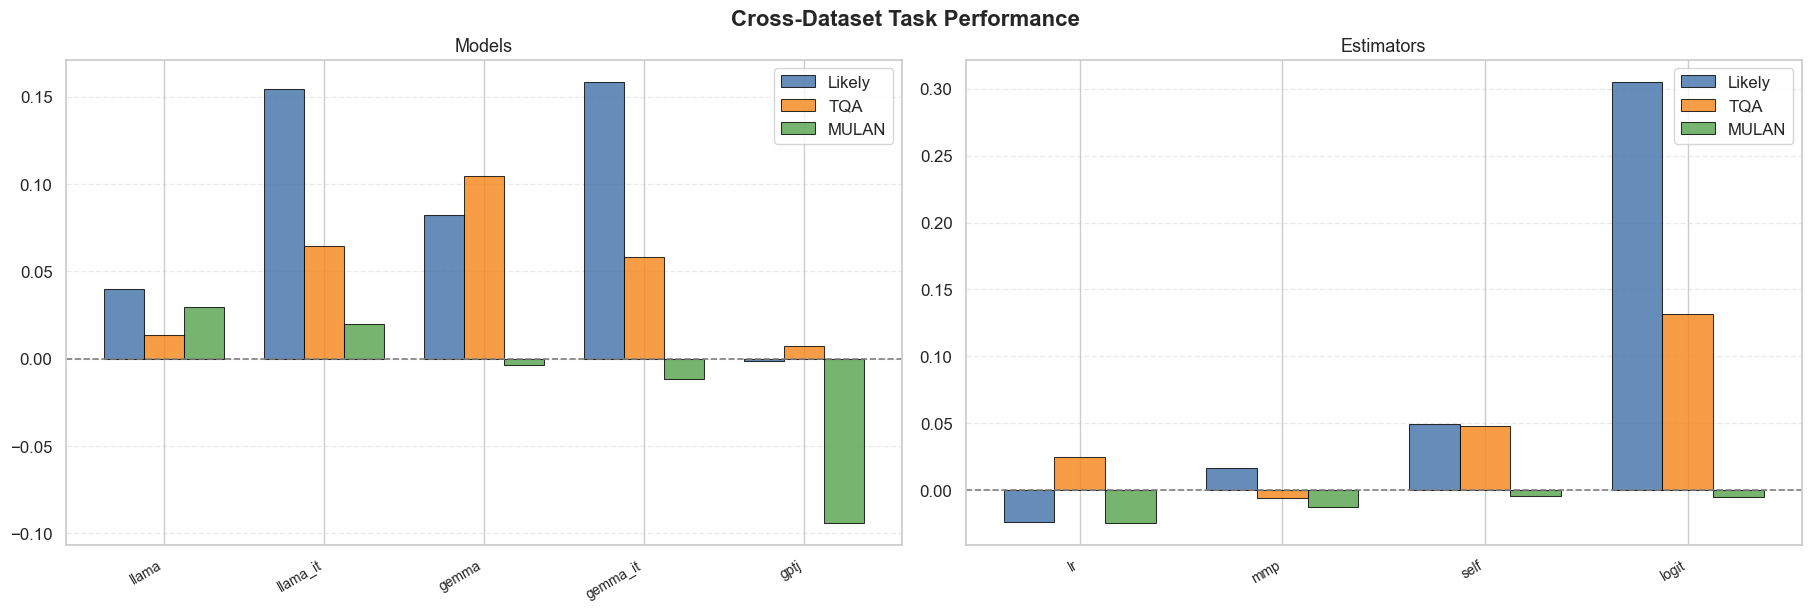

In [ ]:
def get_means(data_dict):
    return {
        name: {k: np.mean(v) for k, v in metrics.items()}
        for name, metrics in data_dict.items()
    }

model_means = get_means(cross_models)
estimator_means = get_means(cross_estimators)

def extract_plot_data(means_dict):
    labels = list(means_dict.keys())
    likely_vals = [means_dict[k]['likely'] for k in labels]
    tqa_vals = [means_dict[k]['tqa'] for k in labels]
    mulan_vals = [means_dict[k]['mulan'] for k in labels]
    return labels, likely_vals, tqa_vals, mulan_vals

model_labels, model_likely, model_tqa, model_mulan = extract_plot_data(model_means)
est_labels, est_likely, est_tqa, est_mulan = extract_plot_data(estimator_means)

width = 0.25
colors = ['#4070A8', '#F58518', '#54A24B'] # Blue, Orange, Green

fig, axs = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
fig.suptitle("Cross-Dataset Task Performance", fontsize=16, fontweight='bold')

def plot_bars(ax, x, labels, vals1, vals2, vals3, title):
    ax.bar(x - width, vals1, width, label='Likely', color=colors[0],
           alpha=0.8, edgecolor='black', linewidth=0.75)
    ax.bar(x, vals2, width, label='TQA', color=colors[1],
           alpha=0.8, edgecolor='black', linewidth=0.75)
    ax.bar(x + width, vals3, width, label='MULAN', color=colors[2],
           alpha=0.8, edgecolor='black', linewidth=0.75)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
    ax.axhline(0, color='gray', linestyle='dashed', linewidth=1.2)
    ax.set_title(title, fontsize=13)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend()

x1 = np.arange(len(model_labels))
plot_bars(axs[0], x1, model_labels, model_likely, model_tqa, model_mulan, "Models")
x2 = np.arange(len(est_labels))
plot_bars(axs[1], x2, est_labels, est_likely, est_tqa, est_mulan, "Estimators")

plt.show()



In [ ]:
all_metrics = np.column_stack((neg, disj, conj, inf_, inf))
all_metrics_one_inf = np.column_stack((neg, disj, conj, inf))
scaler = StandardScaler()
standardized_metrics = scaler.fit_transform(all_metrics)
standardized_metrics_one_inf = np.column_stack((neg, disj, conj, inf))

### Irwin-Hall example

(array([ 7.,  9., 17., 17., 24., 24., 24., 38., 33., 39., 48., 48., 49.,
        61., 57., 54., 68., 59., 42., 51., 35., 31., 36., 32., 29., 27.,
        13., 11., 12.,  5.]),
 array([0.03176182, 0.0960893 , 0.16041678, 0.22474426, 0.28907174,
        0.35339923, 0.41772671, 0.48205419, 0.54638167, 0.61070915,
        0.67503664, 0.73936412, 0.8036916 , 0.86801908, 0.93234656,
        0.99667405, 1.06100153, 1.12532901, 1.18965649, 1.25398397,
        1.31831146, 1.38263894, 1.44696642, 1.5112939 , 1.57562138,
        1.63994886, 1.70427635, 1.76860383, 1.83293131, 1.89725879,
        1.96158627]),
 <BarContainer object of 30 artists>)

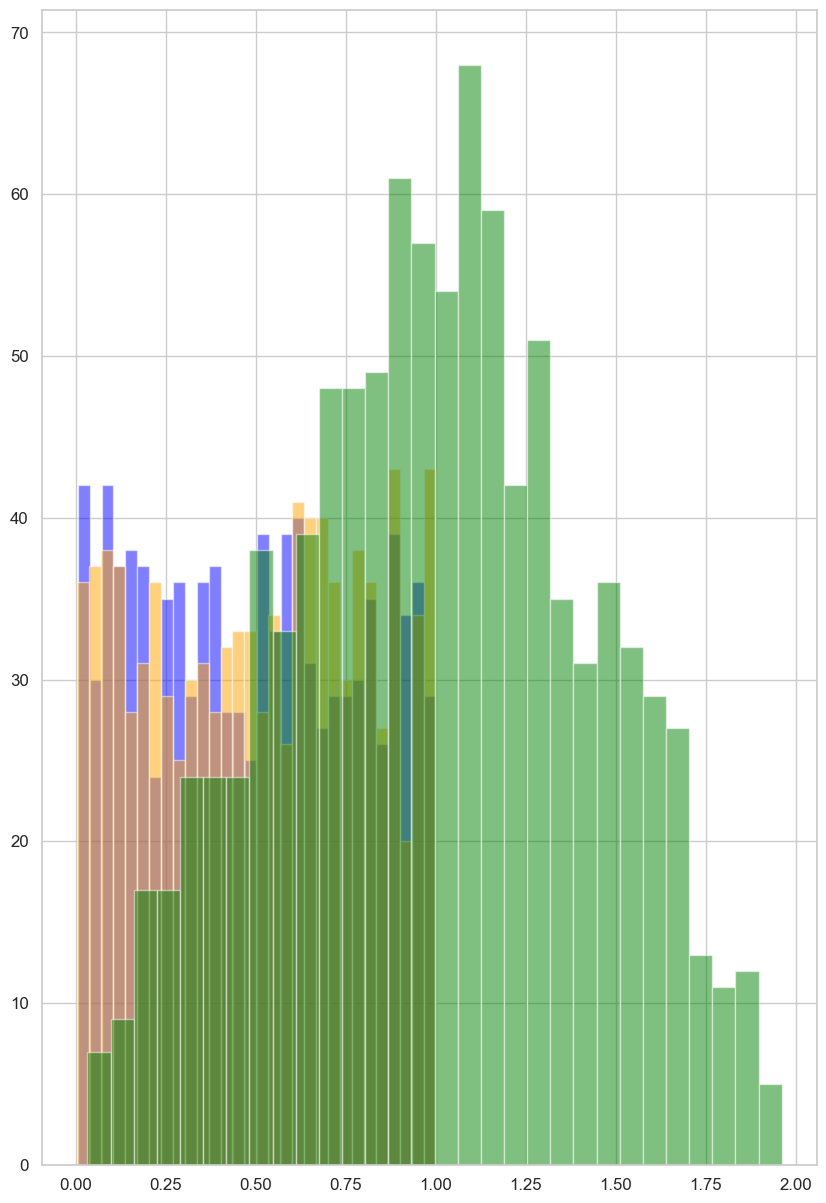

In [ ]:
''' Check Irwin-Hall '''

import matplotlib.pyplot as plt

t1 = np.random.rand(1000)
t2 = np.random.rand(1000)
t3 = t1 + t2

plt.figure(figsize=(10, 15))
plt.hist(t1, bins=30, alpha=0.5, color='blue', label='t1')
plt.hist(t2, bins=30, alpha=0.5, color='orange', label='t2')
plt.hist(t3, bins=30, alpha=0.5, color='green', label='t3')

## It vs Base

In [ ]:
it_self = np.stack((standardized_metrics[6, :].T, standardized_metrics[14, :].T))
base_self = np.stack((standardized_metrics[2, :].T, standardized_metrics[10, :].T))
self_delta = np.mean(it_self - base_self)
it_logit = np.stack((standardized_metrics[7, :].T, standardized_metrics[15, :].T))
base_logit = np.stack((standardized_metrics[3, :].T, standardized_metrics[11, :].T))
logit_delta = np.mean(it_logit - base_logit)
it_lr = np.stack((standardized_metrics[4, :].T, standardized_metrics[12, :].T))
base_lr = np.stack((standardized_metrics[0, :].T, standardized_metrics[8, :].T))
lr_delta = np.mean(it_lr - base_lr)
it_mm = np.stack((standardized_metrics[5, :].T, standardized_metrics[13, :].T))
base_mm = np.stack((standardized_metrics[1, :].T, standardized_metrics[9, :].T))
mm_delta = np.mean(it_mm - base_mm)

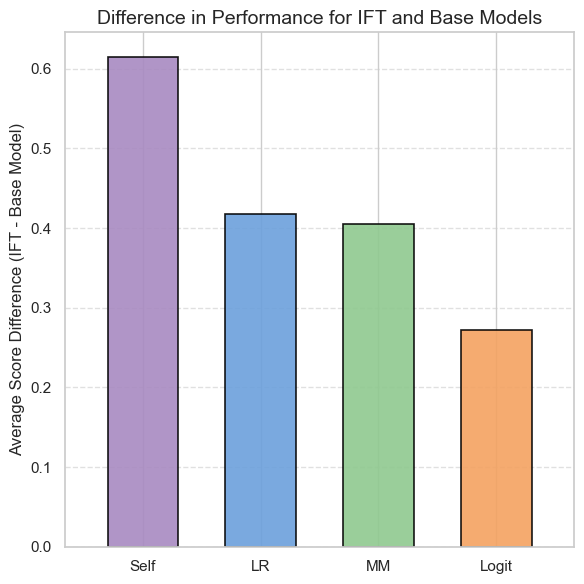

In [ ]:
labels = ['Self', 'Logit', 'LR', 'MM']
deltas = [self_delta, logit_delta, lr_delta, mm_delta]
colors = {
    'Self': '#a88ac1',   # soft purple
    'Logit': '#f4a261',  # soft orange
    'LR': '#6ca0dc',     # soft blue
    'MM': '#8fc98f'      # soft green
}

sorted_items = sorted(zip(labels, deltas), key=lambda x: x[1], reverse=True)
sorted_labels, sorted_deltas = zip(*sorted_items)
sorted_colors = [colors[label] for label in sorted_labels]

plt.figure(figsize=(6, 6))
bars = plt.bar(
    sorted_labels,
    sorted_deltas,
    color=sorted_colors,
    alpha=0.9,
    edgecolor='black',
    linewidth=1.2,
    width=0.6
)


plt.ylabel('Average Score Difference (IFT - Base Model)', fontsize=12)
plt.title('Difference in Performance for IFT and Base Models', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.margins(x=0.1)
plt.tight_layout()

plt.show()


In [ ]:
llama = standardized_metrics[0:4, :].T
llama_it = standardized_metrics[4:8, :].T
gemma = standardized_metrics[8:12, :].T
gemma_it = standardized_metrics[12:16, :].T
gpt_j = standardized_metrics[16:20, :].T
baseline = standardized_metrics[-1:, :].T
lr = np.stack((standardized_metrics[0, :].T, standardized_metrics[4, :].T,
             standardized_metrics[8, :].T, standardized_metrics[12, :].T, standardized_metrics[16, :].T))
lr_random = np.array([-0.26934981, 0.09518319, -0.09170219, -2.77262399])
mm = np.stack((standardized_metrics[1, :].T, standardized_metrics[5, :].T,
             standardized_metrics[9, :].T, standardized_metrics[13, :].T, standardized_metrics[17, :].T))
mm_random = np.array([-0.64496456, 0.09518319, -0.09170219, -2.77262399])
self = np.stack((standardized_metrics[2, :].T, standardized_metrics[6, :].T,
             standardized_metrics[10, :].T, standardized_metrics[14, :].T, standardized_metrics[18, :].T))
self_random = np.array([0.3023748, 0.09518319, -0.09170219, -2.77262399])
logit = np.stack((standardized_metrics[3, :].T, standardized_metrics[7, :].T,
             standardized_metrics[11, :].T, standardized_metrics[15, :].T, standardized_metrics[19, :].T))
logit_random = np.array([0.85964074, 0.09518319, -0.09170219, -2.77262399])

In [ ]:
estimators = {
              'lr': lr.flatten(),
              'mm': mm.flatten(),
              'self': self.flatten(),
              'logit': logit.flatten(),
              'lr_random': lr_random,
              'mm_random': mm_random,
              'self_random': self_random,
              'logit_random': logit_random
              }
models = {
            'llama': llama.flatten(),
            'llama-it': llama_it.flatten(),
            'gemma': gemma.flatten(),
            'gemma-it': gemma_it.flatten(),
            'gpt-j': gpt_j.flatten(),
            'baseline': baseline.flatten()
            }

C:\Users\aless\AppData\Local\Temp\ipykernel_13344\1839671152.py:16: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.boxplot(


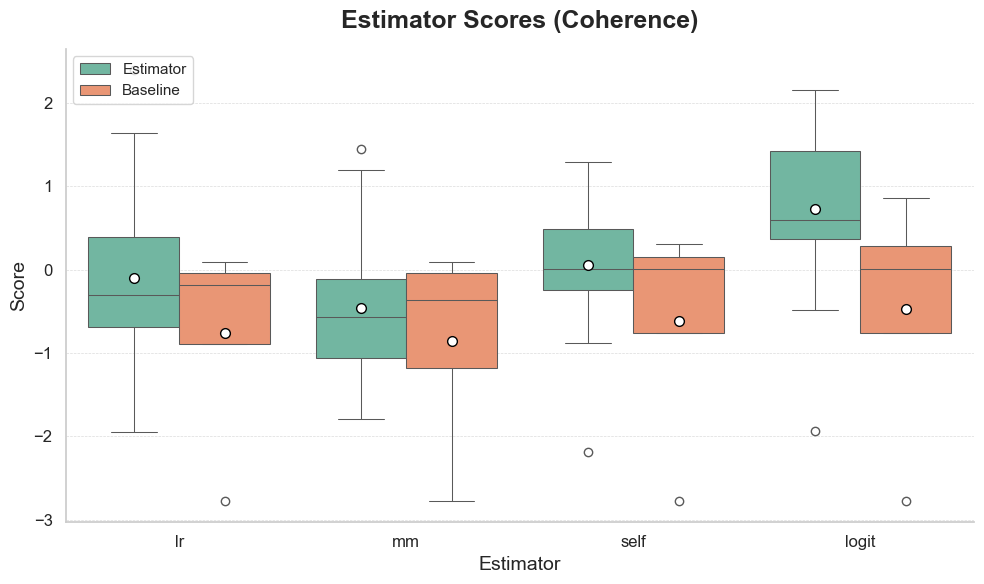

In [ ]:
data = []
for key, values in estimators.items():          # Or models
    model = key.replace('_random', '')
    variant = 'Baseline' if 'random' in key else 'Estimator'
    for v in values:
        data.append({'Model': model, 'Variant': variant, 'Score': float(v)})

df = pd.DataFrame(data)
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
model_order = ['lr', 'mm', 'self', 'logit']

sns.set_theme(style='whitegrid')
palette = sns.color_palette('Set2')

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='Model',
    y='Score',
    hue='Variant',
    order=model_order,
    palette=palette,
    width=0.8,
    linewidth=0.75,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
)

plt.title('Estimator Scores (Coherence)', fontsize=18, weight='bold', pad=15)
plt.xlabel('Estimator', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='', title_fontsize=13, fontsize=11, loc='upper left')
sns.despine(trim=False)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
models = {
    'LR (Base model)': base_lr.flatten(),
    'LR (IFT)': it_lr.flatten(),
    'MM (Base model)': base_mm.flatten(),
    'MM (IFT)': it_mm.flatten(),
    'Self-reporting (Base model)': base_self.flatten(),
    'Self-reporting (IFT)': it_self.flatten(),
    'Logits (Base model)': base_logit.flatten(),
    'Logits (IFT)': it_logit.flatten(),
            }

['#3030c9', '#d0e1ff', '#3030c9', '#d0e1ff', '#3030c9', '#d0e1ff', '#3030c9', '#d0e1ff']


C:\Users\aless\AppData\Local\Temp\ipykernel_13344\3066973129.py:32: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.boxplot(


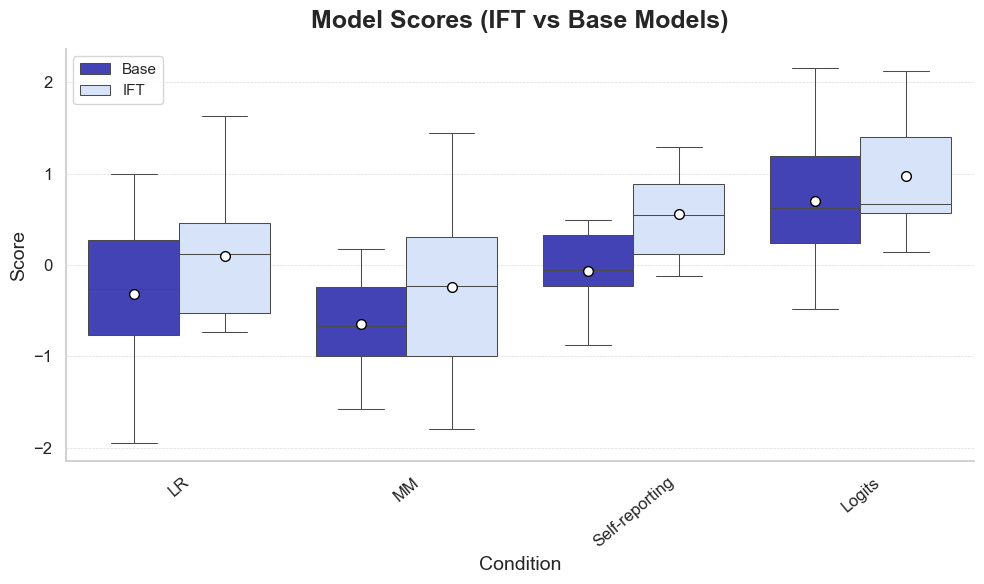

In [ ]:
data = []
for key, values in models.items():
    variant = 'Base' if not key.endswith('IFT)') else 'IFT'
    for v in values:
        data.append({'Model': key, 'Variant': variant, 'Score': float(v)})

df = pd.DataFrame(data)
df[['Model_Name', 'Variant']] = df['Model'].str.extract(r'^(.*?)\s*\((.*?)\)$')
df['Variant'] = df['Variant'].replace({
    'Base model': 'Base',
    'IFT': 'IFT'
})

model_order = df['Model_Name'].unique()
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

sns.set_theme(style='whitegrid')

unique_models = sorted(df['Model'].unique())
light_color = '#3030c9'  # light blue
dark_color = '#d0e1ff'
model_colors = {}

for i, model in enumerate(unique_models):
    model_colors[model] = light_color if i % 2 == 0 else dark_color

palette = df['Model'].map(model_colors).to_dict()
custom_palette = [model_colors[model] for model in df['Model'].unique()]
print(custom_palette)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='Model_Name',
    y='Score',
    hue='Variant',
    palette=custom_palette,
    width=0.8,
    linewidth=0.75,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
)

plt.title('Model Scores (IFT vs Base Models)', fontsize=18, weight='bold', pad=15)
plt.xlabel('Condition', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(fontsize=12, rotation=40)
plt.yticks(fontsize=12)
plt.legend(title='', title_fontsize=13, fontsize=11, loc='upper left')
sns.despine(trim=False)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Change the indices based on the task.

test_lr = [split[0, 4] for split in np.array_split(lr, 5)]
test_lr_baseline = lr_random[3]
test_mm = [split[0, 4] for split in np.array_split(mm, 5)]
test_mm_baseline = mm_random[3]
test_self = [split[0, 4] for split in np.array_split(self, 5)]
test_self_baseline = self_random[3]
test_logit = [split[0, 4] for split in np.array_split(logit, 5)]
test_logit_baseline = logit_random[3]

In [ ]:
lr_score = np.mean(test_lr)
lr_random_score = np.mean(lr_random)
mm_score = np.mean(test_mm)
mm_random_score = np.mean(mm_random)
self_score = np.mean(test_self)
self_random_score = np.mean(self_random)
logit_score = np.mean(test_logit)
logit_random_score = np.mean(logit_random)


scores = {
    'lr': lr_score,
    'mm': mm_score,
    'self': self_score,
    'logit': logit_score,
    'lr_random': test_lr_baseline,
    'mm_random': test_mm_baseline,
    'self_random': test_self_baseline,
    'logit_random': test_logit_baseline
}

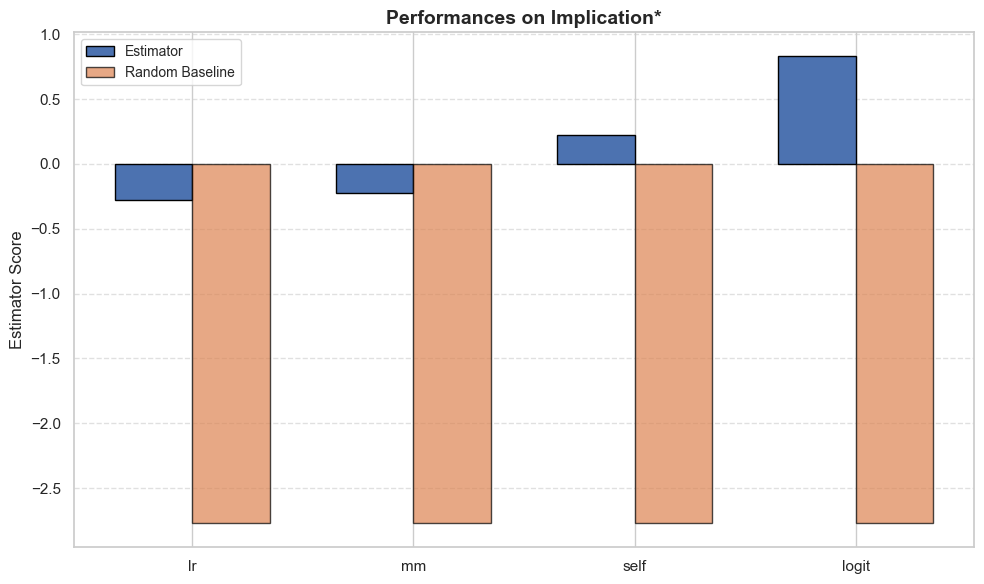

In [ ]:
model_names = ["lr", "mm", "self", "logit"]
actual_scores = [scores["lr"], scores["mm"], scores["self"], scores["logit"]]
random_scores = [scores["lr_random"], scores["mm_random"], scores["self_random"], scores["logit_random"]]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, actual_scores, width, label='Estimator', edgecolor='black')
bars2 = ax.bar(x + width/2, random_scores, width, label='Random Baseline', edgecolor='black', alpha=0.7)

ax.set_ylabel("Estimator Score", fontsize=12)
ax.set_title("Performances on Implication*", fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Self-consistency study

Results for self-consistency. The single curves can be seen in exp2.ipynb

In [ ]:
errors = {'llama': {'ece': {'lr': 0.118, 'mmp': 0.118, 'self': 0.1720}, 'mce': {'lr': 0.26, 'mmp': 0.232, 'self': 0.439}},
          'llama-it': {'ece': {'lr': 0.069, 'mmp': 0.1470, 'self': 0.063}, 'mce': {'lr': 0.1920, 'mmp': 0.2570, 'self': 0.1510}},
          'gemma': {'ece': {'lr': 0.068, 'mmp': 0.117, 'self': 0.086}, 'mce': {'lr': 0.16, 'mmp': 0.237, 'self': 0.293}},
          'gemma-it': {'ece': {'lr': 0.066, 'mmp': 0.089, 'self': 0.028}, 'mce': {'lr': 0.263, 'mmp': 0.263, 'self': 0.111}},
          'gptj': {'ece': {'lr': 0.283, 'mmp': 0.379, 'self': 0.256}, 'mce': {'lr': 0.544, 'mmp': 0.621, 'self': 0.519}}}

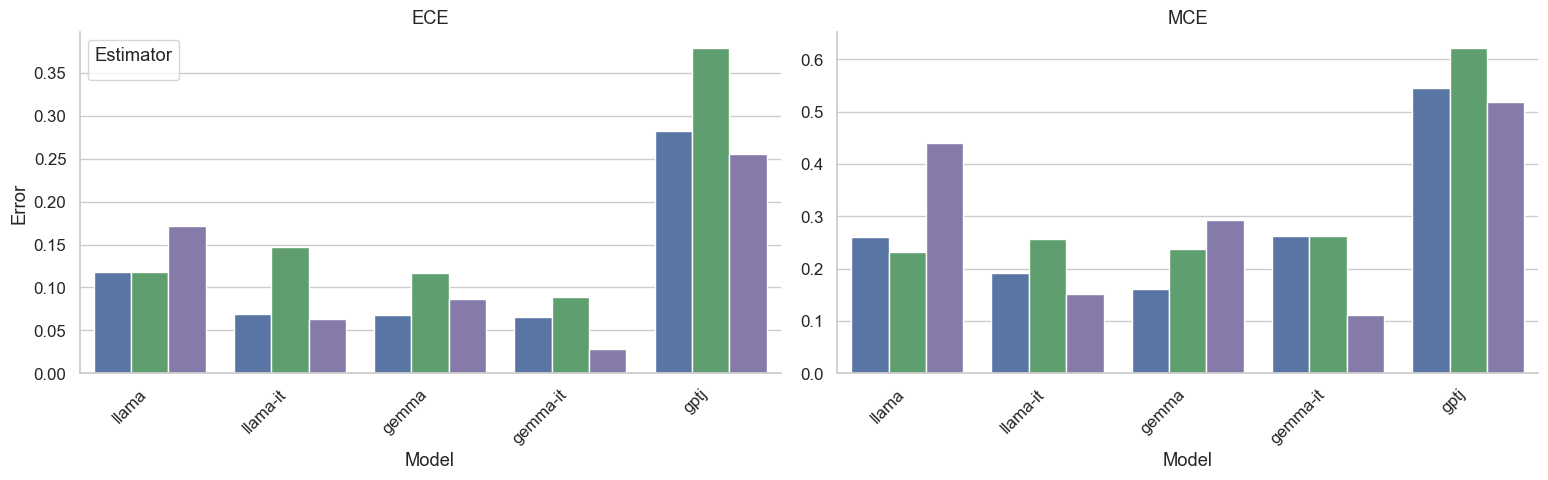

In [ ]:
# Flatten the nested dictionary into a DataFrame
rows = []
for model, metrics in errors.items():
    for error_type, methods in metrics.items():
        for method, value in methods.items():
            rows.append({
                'Model': model,
                'Error Type': error_type.upper(),  # ECE or MCE
                'Calibration Method': method,
                'Error Value': value
            })

df = pd.DataFrame(rows)

# Set desired color palette
palette = {
    'lr': '#4C72B0',     # default blue
    'mmp': '#55A868',    # green
    'self': '#8172B2'    # purple
}

# Sort calibration method to keep bar order consistent
df['Calibration Method'] = pd.Categorical(df['Calibration Method'], categories=['lr', 'mmp', 'self'], ordered=True)

# Plot
sns.set(style="whitegrid", font_scale=1.1)
g = sns.catplot(
    data=df,
    x='Model',
    y='Error Value',
    hue='Calibration Method',
    col='Error Type',
    kind='bar',
    height=5,
    aspect=1.4,
    palette=palette,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Model", "Error")
# Remove shared legend
g._legend.remove()

# Add it to first subplot (ECE)
handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.axes[0, 0].legend(
    handles, labels,
    loc='upper left',
    title='Estimator',
    frameon=True  # optional: removes border around legend
)
g.set_xticklabels(rotation=45, ha='right')

# Rotate x labels
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

